In [1]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 19.3 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.2.3
    Uninstalling sentence-transformers-5.2.3:
      Successfully uninstalled sentence-transformers-5.2.3


In [2]:
# ============================================================
# 🚀 MOTION-S OPTIMIZED TF-IDF (TOP-3 + SMART SELECT)
# ============================================================

import os, re, random
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

In [3]:
# ============================================================
# CONFIG
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

TOP_K = 3
MIN_LEN, MAX_LEN = 40, 800

# threshold for "confident match"
DIST_THRESHOLD = 0.12  

INPUT_DIR = Path("/kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language")

train = pd.read_csv(INPUT_DIR / "train.csv")
test  = pd.read_csv(INPUT_DIR / "test.csv")

print("Train:", train.shape)
print("Test:", test.shape)

Train: (12467, 10)
Test: (3000, 3)


In [4]:
# ============================================================
# TEXT PROCESSING
# ============================================================
_ws_re = re.compile(r"\s+")

def norm_text(x):
    if not isinstance(x, str):
        return ""
    return _ws_re.sub(" ", x.strip())

def build_text(df):
    g = df["gloss"].map(norm_text)
    s = df["sentence"].map(norm_text)
    # stronger gloss weighting
    return (g + " || " + g + " || " + g + " || " + s).fillna("")

train_text = build_text(train)
test_text  = build_text(test)

In [5]:
# ============================================================
# TOKEN UTILS
# ============================================================
TOKEN_COLS = ["base_tokens", "residual_1", "residual_2",
              "residual_3", "residual_4", "residual_5"]

def parse_tokens(x):
    if not isinstance(x, str) or x.strip() == "":
        return []
    return [int(t) for t in x.split()]

def tokens_to_str(t):
    return " ".join(map(str, t))

def enforce_len(tokens, target_len):
    if len(tokens) == 0:
        return [random.randint(0, 511) for _ in range(target_len)]
    if len(tokens) < target_len:
        reps = (target_len + len(tokens) - 1) // len(tokens)
        tokens = (tokens * reps)[:target_len]
    if len(tokens) > target_len:
        tokens = tokens[:target_len]
    return tokens

In [6]:
# ============================================================
# CLEAN DATA
# ============================================================
good_mask = np.ones(len(train), dtype=bool)

for i, row in train.iterrows():
    lens = []
    ok = True
    for c in TOKEN_COLS:
        t = parse_tokens(row[c])
        if any((x < 0 or x > 511) for x in t):
            ok = False
            break
        lens.append(len(t))
    if (not ok) or (len(set(lens)) != 1) or (lens[0] < 1):
        good_mask[i] = False

train_good = train.loc[good_mask].reset_index(drop=True)
train_text_good = train_text.loc[good_mask].reset_index(drop=True)

print("Usable train:", len(train_good))

# Cache tokens
train_tokens_cache = {
    c: [parse_tokens(x) for x in train_good[c].astype(str)]
    for c in TOKEN_COLS
}

Usable train: 12463


In [7]:
# ============================================================
# Sentence Transformer
# ============================================================
from sentence_transformers import SentenceTransformer

# 1. Model Yükleme (Hafif ve hızlı bir model)
model = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Cümleleri Vektöre Çevirme
# Not: build_text fonksiyonun hala geçerli
print("Encoding train sentences...")
X_train = model.encode(train_text_good.tolist(), show_progress_bar=True, convert_to_numpy=True)

print("Encoding test sentences...")
X_test = model.encode(test_text.tolist(), show_progress_bar=True, convert_to_numpy=True)

print("SBERT Embeddings done:", X_train.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Encoding train sentences...


Batches:   0%|          | 0/390 [00:00<?, ?it/s]

Encoding test sentences...


Batches:   0%|          | 0/94 [00:00<?, ?it/s]

SBERT Embeddings done: (12463, 384)


In [8]:
# ============================================================
# NEAREST NEIGHBORS (TOP-K)
# ============================================================
nn = NearestNeighbors(n_neighbors=TOP_K, metric="cosine", algorithm="brute")
nn.fit(X_train)

dist, idx = nn.kneighbors(X_test)

print("Retrieval done")

# ============================================================
# 🧠 SMART SELECTION FUNCTION
# ============================================================
def choose_neighbor(dists):
    # If best match is very strong → take it
    if dists[0] < DIST_THRESHOLD:
        return 0
    # otherwise pick best anyway (safe)
    return 0


Retrieval done


In [9]:
# ============================================================
# 🚀 PREDICTION
# ============================================================
pred = pd.DataFrame({"id": test["id"].values})

for c in TOKEN_COLS:
    pred[c] = ""

print("Generating predictions...")

for i in tqdm(range(len(test))):

    dists = dist[i]
    neighbors = idx[i]

    # choose best neighbor
    chosen_idx = neighbors[choose_neighbor(dists)]

    # get tokens
    layers = [train_tokens_cache[c][chosen_idx] for c in TOKEN_COLS]

    # 🔥 BETTER LENGTH SELECTION
    lengths = [len(l) for l in layers if len(l) > 0]
    if len(lengths) == 0:
        L = MIN_LEN
    else:
        L = int(np.clip(np.median(lengths), MIN_LEN, MAX_LEN))

    # enforce same length
    fixed_layers = []
    for l in layers:
        fixed_layers.append(enforce_len(l, L))

    # 🔥 SMALL DIVERSITY NOISE
    for layer in fixed_layers:
        for t in range(len(layer)):
            if random.random() < 0.01:  # very small
                layer[t] = int(np.clip(layer[t] + random.choice([-1,1]), 0, 511))

    # assign
    for j, c in enumerate(TOKEN_COLS):
        pred.at[i, c] = tokens_to_str(fixed_layers[j])



Generating predictions...


100%|██████████| 3000/3000 [00:01<00:00, 2420.58it/s]


In [10]:
# ============================================================
# SAVE
# ============================================================
OUT_PATH = Path("/kaggle/working/submission_tfidf_v2.csv")
pred.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
display(pred.head())

Saved: /kaggle/working/submission_tfidf_v2.csv


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 322 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 260 9 207 207 207 449 277 457 212 212 268 ...,145 441 214 184 184 113 155 405 26 423 440 300...,246 396 444 454 454 201 466 212 441 303 166 28...,34 292 246 259 479 72 332 474 378 467 451 298 ...,10 128 498 317 104 159 328 111 204 447 447 100...,486 185 367 437 476 203 256 358 353 398 457 39...
2,6425789,130 276 174 174 145 145 145 174 174 50 50 50 2...,339 194 389 88 87 173 87 333 287 97 79 79 289 ...,406 48 286 286 453 346 6 321 325 354 348 246 4...,351 463 336 401 401 308 236 401 134 72 353 353...,64 32 353 456 409 222 290 74 320 498 156 318 2...,257 261 367 367 372 241 239 409 249 137 350 22...
3,6425858,130 276 174 174 174 145 145 174 174 50 50 50 2...,339 194 389 88 88 173 173 333 287 97 79 79 289...,406 48 452 286 321 346 346 321 325 353 348 75 ...,351 463 449 401 308 236 236 424 134 96 333 195...,64 32 234 456 111 361 361 498 320 17 498 318 2...,257 261 367 367 372 241 241 241 249 343 295 50...
4,6427530,130 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 87 87 333 258 333 258 258 9 333 333 33...,48 48 202 356 356 6 356 202 202 283 356 356 58...,72 212 315 503 118 457 59 401 448 457 401 395 ...,64 413 316 467 71 71 95 498 270 134 498 498 43...,489 241 367 406 119 9 241 305 266 459 431 241 ...


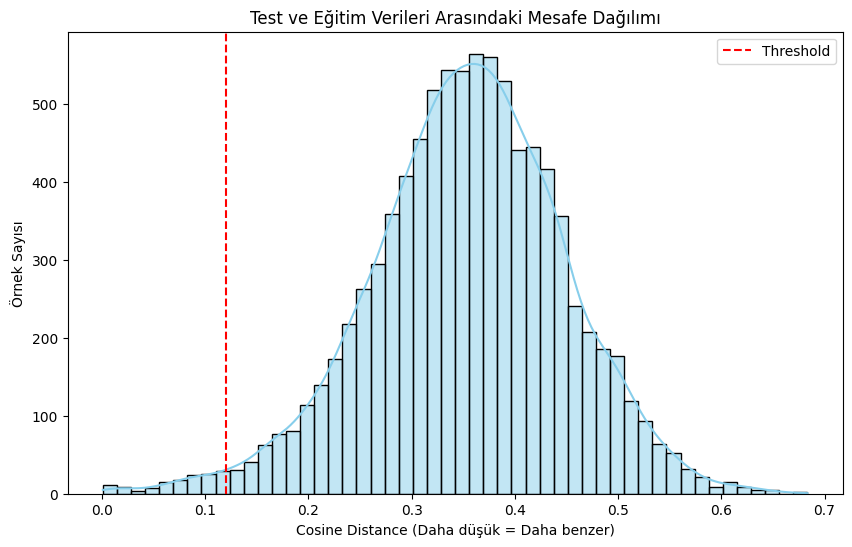

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(dist.flatten(), bins=50, kde=True, color='skyblue')
plt.axvline(x=0.12, color='red', linestyle='--', label='Threshold') # Senin eşik değerin
plt.title('Test ve Eğitim Verileri Arasındaki Mesafe Dağılımı')
plt.xlabel('Cosine Distance (Daha düşük = Daha benzer)')
plt.ylabel('Örnek Sayısı')
plt.legend()
plt.show()

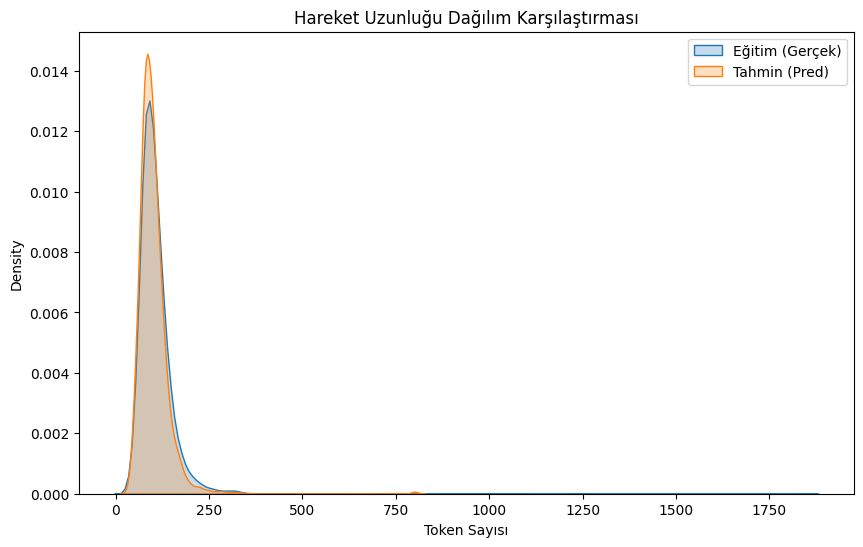

In [12]:
# Eğitim setindeki gerçek uzunlukları hesapla
train_lens = [len(parse_tokens(str(x))) for x in train_good['base_tokens']]
# Tahmin ettiğin uzunlukları hesapla (pred dataframe'inden)
pred_lens = [len(str(x).split()) for x in pred['base_tokens']]

plt.figure(figsize=(10, 6))
sns.kdeplot(train_lens, label='Eğitim (Gerçek)', fill=True)
sns.kdeplot(pred_lens, label='Tahmin (Pred)', fill=True)
plt.title('Hareket Uzunluğu Dağılım Karşılaştırması')
plt.xlabel('Token Sayısı')
plt.legend()
plt.show()

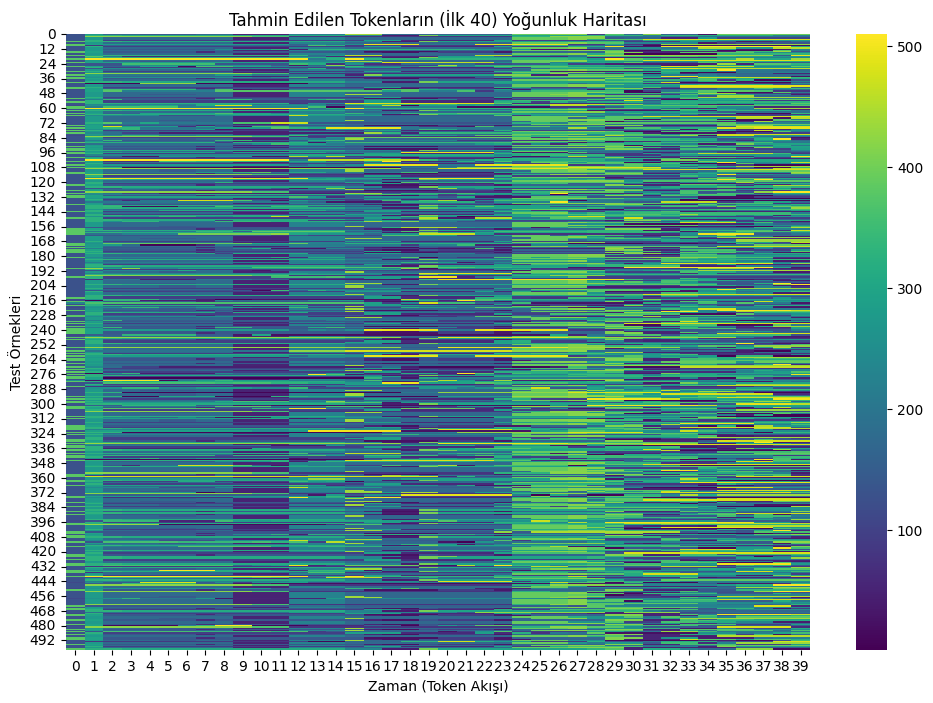

In [13]:
# Rastgele 500 tahminin ilk 40 token'ını görselleştirme
def tokens_to_list(s): return [int(x) for x in str(s).split()[:40]]
sample_tokens = np.array([tokens_to_list(x) for x in pred['base_tokens'].sample(500)])

plt.figure(figsize=(12, 8))
sns.heatmap(sample_tokens, cmap='viridis')
plt.title('Tahmin Edilen Tokenların (İlk 40) Yoğunluk Haritası')
plt.xlabel('Zaman (Token Akışı)')
plt.ylabel('Test Örnekleri')
plt.show()